In [2]:
import pandas as pd

# carregando datasets
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')

In [3]:
orders.shape

(99441, 8)

In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [5]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [6]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [7]:
# tempo de entrega
orders['tempo_entrega'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

# atraso
orders['atrasado'] = orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']

# período
orders['mes_ano'] = orders['order_purchase_timestamp'].dt.to_period('M')

In [8]:
df = orders.merge(payments, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(reviews[['order_id','review_score']], on='order_id', how='left')

In [9]:
df.shape
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,tempo_entrega,atrasado,mes_ano,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,False,2017-10,1.0,credit_card,1.0,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,False,2017-10,3.0,voucher,1.0,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,False,2017-10,2.0,voucher,1.0,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,False,2018-07,1.0,boleto,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,False,2018-08,1.0,credit_card,3.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,5.0


In [10]:
payments_agg = payments.groupby('order_id')['payment_value'].sum().reset_index()

In [11]:
df = orders.merge(payments_agg, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(reviews[['order_id','review_score']], on='order_id', how='left')

In [12]:
pedidos_mes = df.groupby('mes_ano')['order_id'].nunique()

In [13]:
receita_mes = df.groupby('mes_ano')['payment_value'].sum()

In [14]:
ticket_medio = receita_mes / pedidos_mes

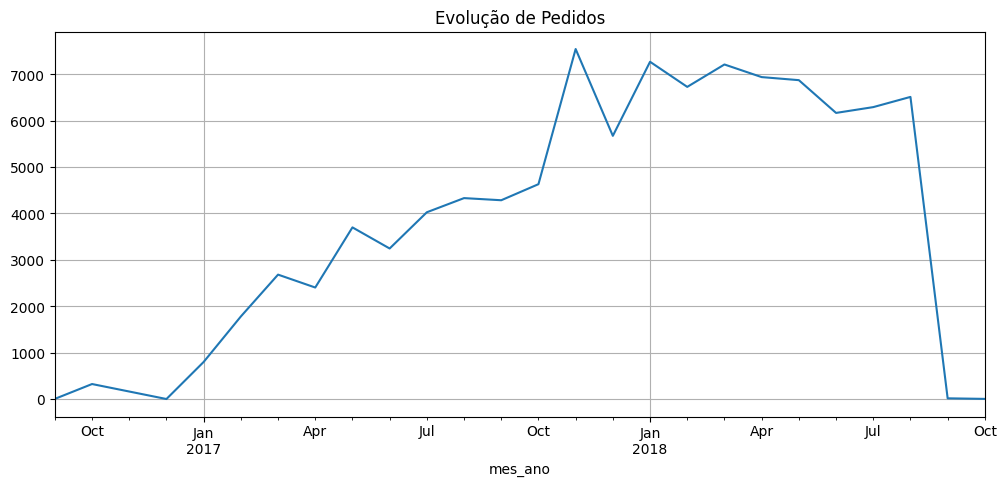

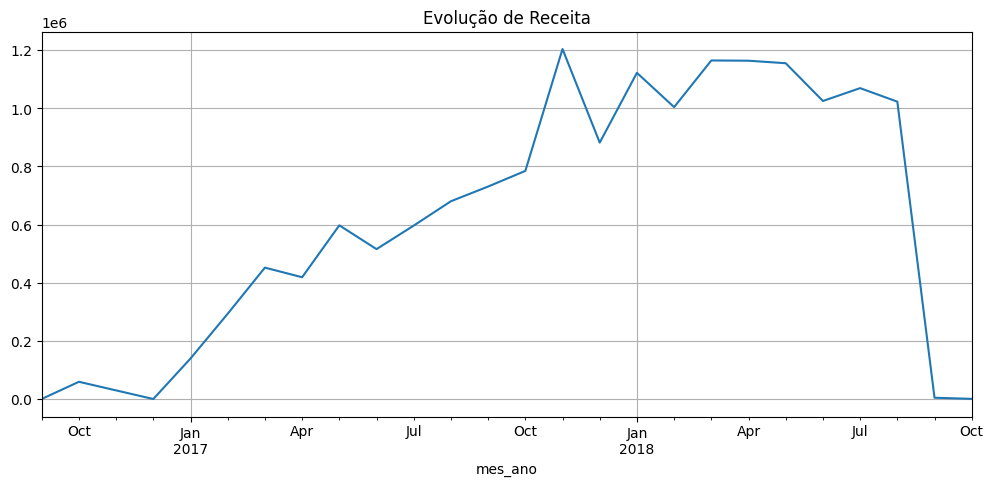

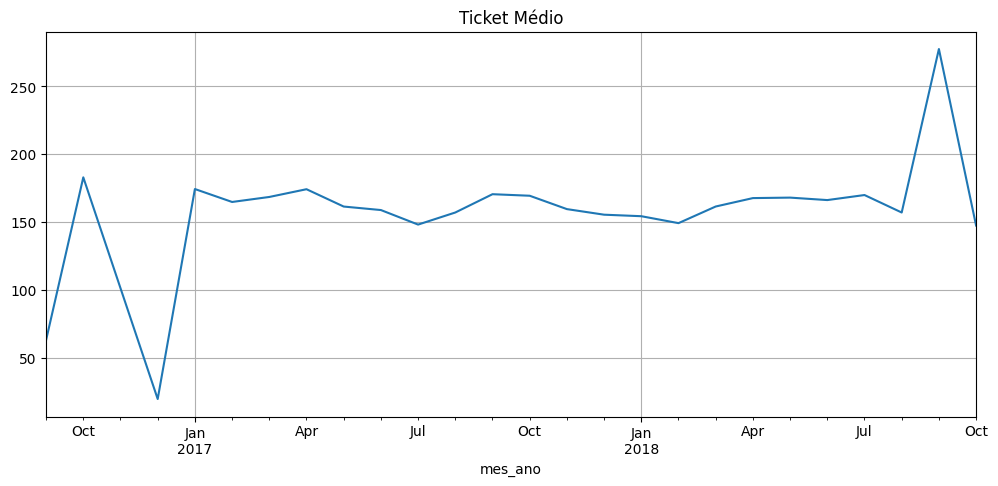

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
pedidos_mes.plot(title='Evolução de Pedidos')
plt.grid()
plt.show()

plt.figure(figsize=(12,5))
receita_mes.plot(title='Evolução de Receita')
plt.grid()
plt.show()

plt.figure(figsize=(12,5))
ticket_medio.plot(title='Ticket Médio')
plt.grid()
plt.show()

In [16]:
df['tempo_entrega'].describe()

,tempo_entrega
count,97005.000000
mean,12.100015
std,9.547959
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [17]:
df.groupby('atrasado')['review_score'].mean()

,review_score
atrasado,
False,4.214307
True,2.566550


In [20]:
df = df[df['order_purchase_timestamp'] < '2018-08-01']

DISTRIBUIÇÃO DE SATISFAÇÃO

<Axes: title={'center': 'Distribuição de Avaliações'}, xlabel='review_score'>

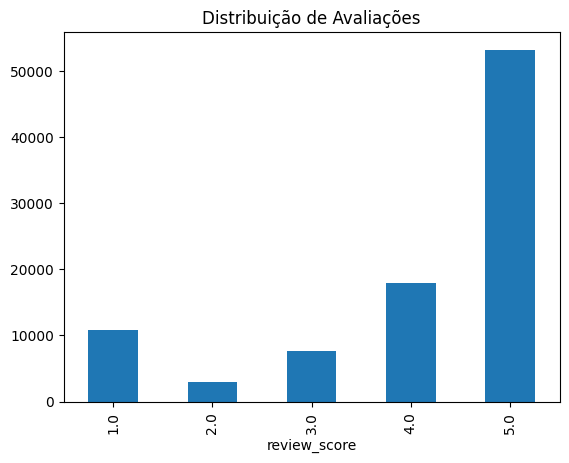

In [19]:
df['review_score'].value_counts().sort_index().plot(kind='bar', title='Distribuição de Avaliações')

IMPACTO DO TEMPO NA NOTA

<Axes: title={'center': 'Tempo de Entrega vs Nota'}, xlabel='tempo_entrega'>

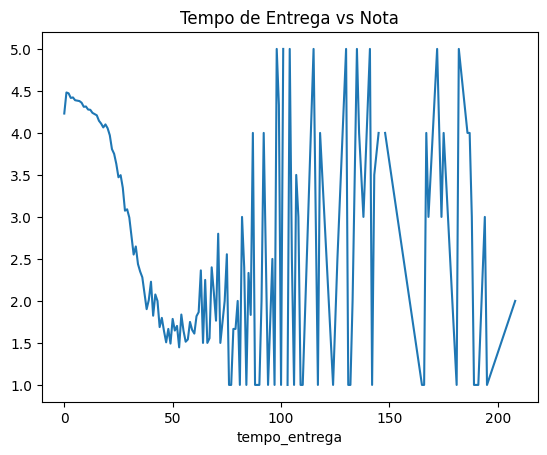

In [21]:
df.groupby('tempo_entrega')['review_score'].mean().plot(title='Tempo de Entrega vs Nota')

CRIAR FAIXAS DE ENTREGA

/tmp/ipykernel_13614/634969973.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('faixa_entrega')['review_score'].mean().plot(kind='bar', title='Nota por Faixa de Entrega')


<Axes: title={'center': 'Nota por Faixa de Entrega'}, xlabel='faixa_entrega'>

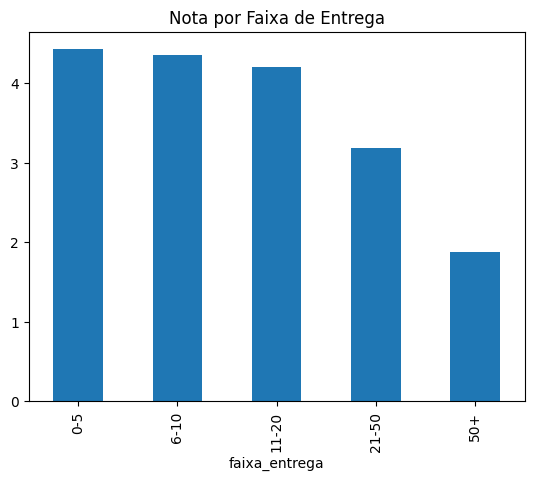

In [22]:
df['faixa_entrega'] = pd.cut(df['tempo_entrega'],
                            bins=[0,5,10,20,50,200],
                            labels=['0-5','6-10','11-20','21-50','50+'])

df.groupby('faixa_entrega')['review_score'].mean().plot(kind='bar', title='Nota por Faixa de Entrega')

TAXA DE ATRASO

In [23]:
df['atrasado'].value_counts(normalize=True)

,proportion
atrasado,
False,0.922907
True,0.077093


IMPACTO FINANCEIRO DO ATRASO

In [24]:
df.groupby('atrasado')['payment_value'].mean()

,payment_value
atrasado,
False,159.923941
True,174.894760


In [25]:
items_agg = items.groupby('order_id')['price'].sum().reset_index()

df = df.merge(items_agg, on='order_id', how='left')

<Axes: title={'center': 'Top Categorias por Receita'}, xlabel='product_category_name'>

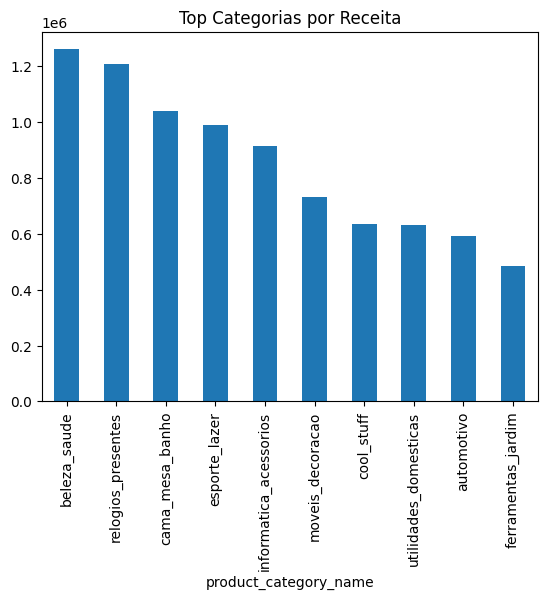

In [26]:
df_cat = items.merge(products, on='product_id', how='left')

top_categorias = df_cat.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)

top_categorias.plot(kind='bar', title='Top Categorias por Receita')

In [27]:
df_full = df_cat.merge(reviews[['order_id','review_score']], on='order_id', how='left')

df_full.groupby('product_category_name')['review_score'].mean().sort_values().head(10)

,review_score
product_category_name,
seguros_e_servicos,2.500000
fraldas_higiene,3.256410
portateis_cozinha_e_preparadores_de_alimentos,3.266667
pc_gamer,3.333333
moveis_escritorio,3.493183
casa_conforto_2,3.629630
fashion_roupa_masculina,3.641221
telefonia_fixa,3.683206
artigos_de_festas,3.767442


In [28]:
# usar apenas pedidos que permaneceram no df filtrado
pedidos_validos = df[['order_id']].drop_duplicates()

df_cat = items.merge(pedidos_validos, on='order_id', how='inner')
df_cat = df_cat.merge(products, on='product_id', how='left')
df_cat = df_cat.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

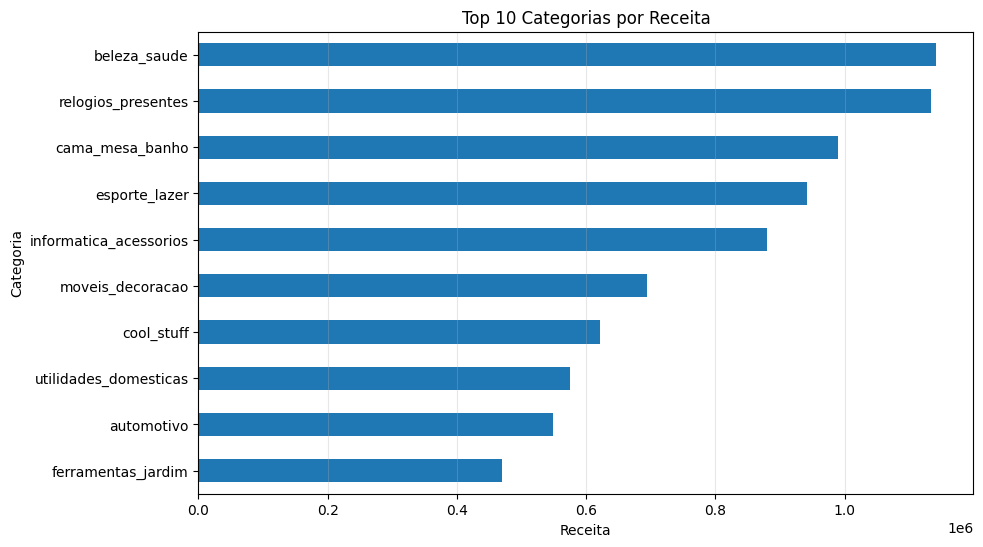

In [29]:
import matplotlib.pyplot as plt

top_categorias = (
    df_cat.groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10,6))
top_categorias.plot(kind='barh')
plt.title('Top 10 Categorias por Receita')
plt.xlabel('Receita')
plt.ylabel('Categoria')
plt.grid(axis='x', alpha=0.3)
plt.show()

In [30]:
cat_satisfacao = (
    df_cat.groupby('product_category_name')
    .agg(
        nota_media=('review_score', 'mean'),
        qtd_avaliacoes=('review_score', 'count'),
        receita=('price', 'sum')
    )
    .reset_index()
)

cat_satisfacao_filtrada = cat_satisfacao[cat_satisfacao['qtd_avaliacoes'] >= 100]

piores_categorias = (
    cat_satisfacao_filtrada
    .sort_values('nota_media')
    .head(10)
)

piores_categorias

,product_category_name,nota_media,qtd_avaliacoes,receita
55,moveis_escritorio,3.482197,1657,268465.62
38,fashion_roupa_masculina,3.617188,128,10416.13
71,telefonia_fixa,3.662698,252,56898.82
7,audio,3.794030,335,48669.00
14,casa_conforto,3.809069,419,56587.46
25,construcao_ferramentas_seguranca,3.832335,167,36474.40
13,cama_mesa_banho,3.884289,10483,989900.73
54,moveis_decoracao,3.892391,7899,694902.32
44,informatica_acessorios,3.911856,7431,879346.61
57,moveis_sala,3.915584,462,64203.92


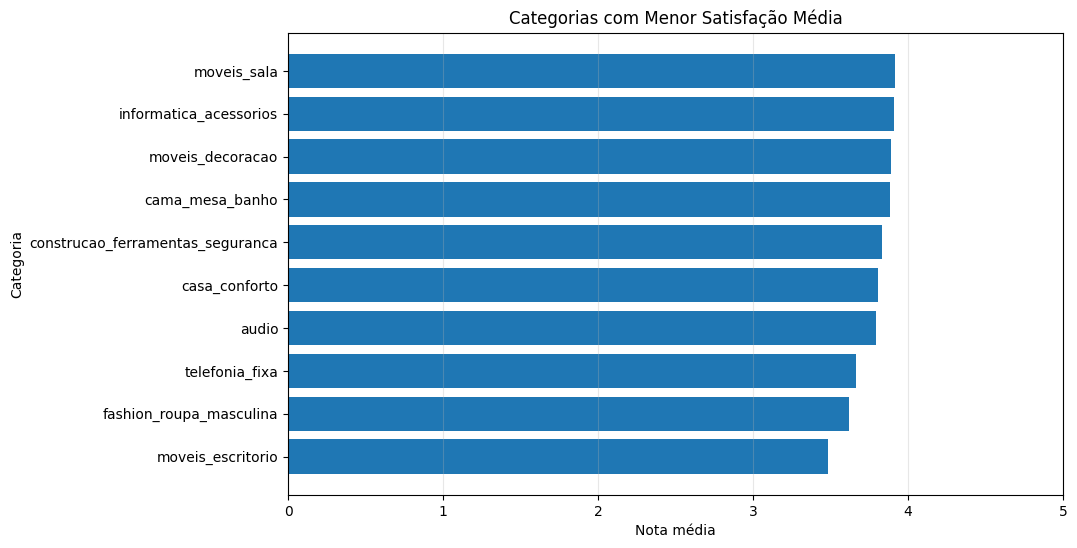

In [31]:
piores_plot = piores_categorias.sort_values('nota_media', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(piores_plot['product_category_name'], piores_plot['nota_media'])
plt.title('Categorias com Menor Satisfação Média')
plt.xlabel('Nota média')
plt.ylabel('Categoria')
plt.xlim(0,5)
plt.grid(axis='x', alpha=0.3)
plt.show()

In [32]:
faixa_entrega = (
    df.groupby('faixa_entrega')
    .agg(
        nota_media=('review_score', 'mean'),
        qtd_pedidos=('order_id', 'nunique'),
        receita=('payment_value', 'sum')
    )
    .reset_index()
)

faixa_entrega

/tmp/ipykernel_13614/76151491.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('faixa_entrega')


,faixa_entrega,nota_media,qtd_pedidos,receita
0,0-5,4.424176,16843,2228289.13
1,6-10,4.351987,30030,4694602.58
2,11-20,4.198242,30815,5263593.50
3,21-50,3.185005,11813,2190455.57
4,50+,1.884746,609,126666.66


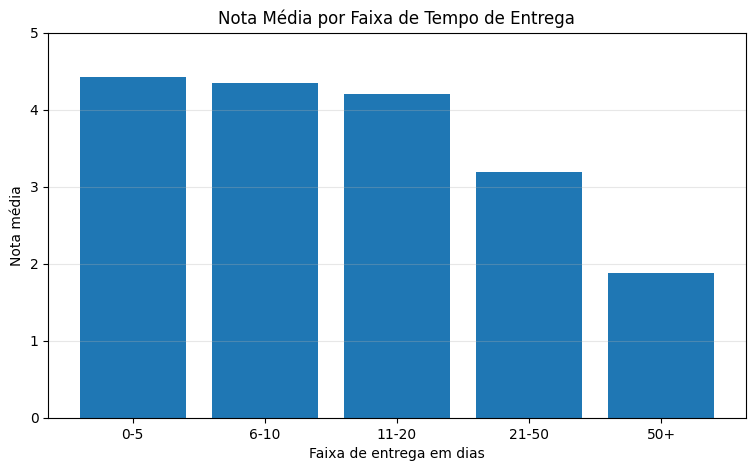

In [33]:
plt.figure(figsize=(9,5))
plt.bar(faixa_entrega['faixa_entrega'].astype(str), faixa_entrega['nota_media'])
plt.title('Nota Média por Faixa de Tempo de Entrega')
plt.xlabel('Faixa de entrega em dias')
plt.ylabel('Nota média')
plt.ylim(0,5)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [34]:
resumo_kpis = {
    'Total de pedidos': df['order_id'].nunique(),
    'Receita total': df['payment_value'].sum(),
    'Ticket médio': df['payment_value'].sum() / df['order_id'].nunique(),
    'Tempo médio de entrega': df['tempo_entrega'].mean(),
    'Taxa de atraso': df['atrasado'].mean(),
    'Nota média': df['review_score'].mean()
}

resumo_kpis

{'Total de pedidos': 92909,
 'Receita total': np.float64(15053861.509999998),
 'Ticket médio': np.float64(162.0280221507066),
 'Tempo médio de entrega': np.float64(12.437342805453824),
 'Taxa de atraso': np.float64(0.07709345374392776),
 'Nota média': np.float64(4.074980047024311)}

Receita por estado

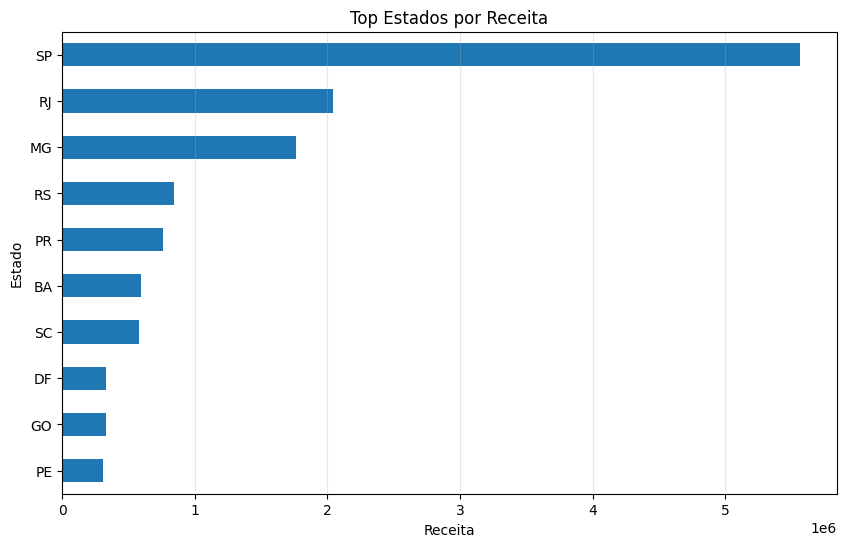

In [35]:
receita_estado = (
    df.groupby('customer_state')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
receita_estado.sort_values().plot(kind='barh')
plt.title('Top Estados por Receita')
plt.xlabel('Receita')
plt.ylabel('Estado')
plt.grid(axis='x', alpha=0.3)
plt.show()

Pedidos por estado

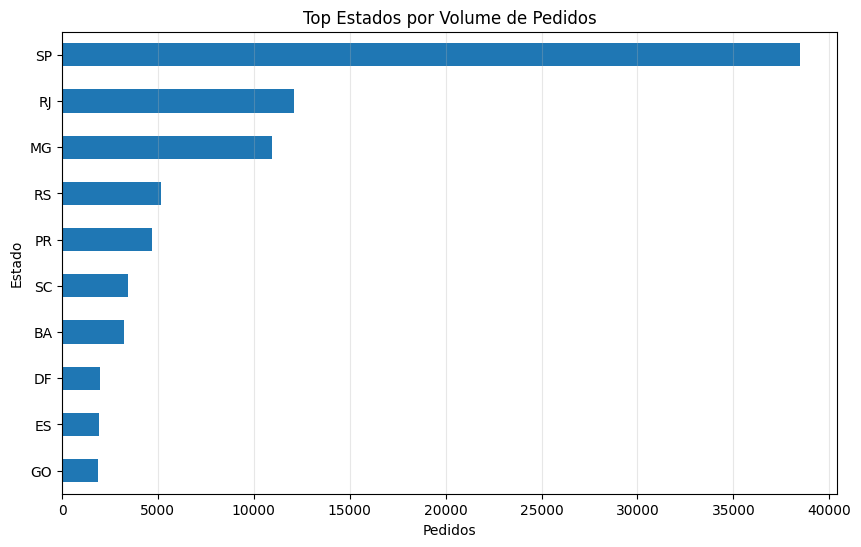

In [36]:
pedidos_estado = (
    df.groupby('customer_state')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
pedidos_estado.sort_values().plot(kind='barh')
plt.title('Top Estados por Volume de Pedidos')
plt.xlabel('Pedidos')
plt.ylabel('Estado')
plt.grid(axis='x', alpha=0.3)
plt.show()

Taxa de atraso

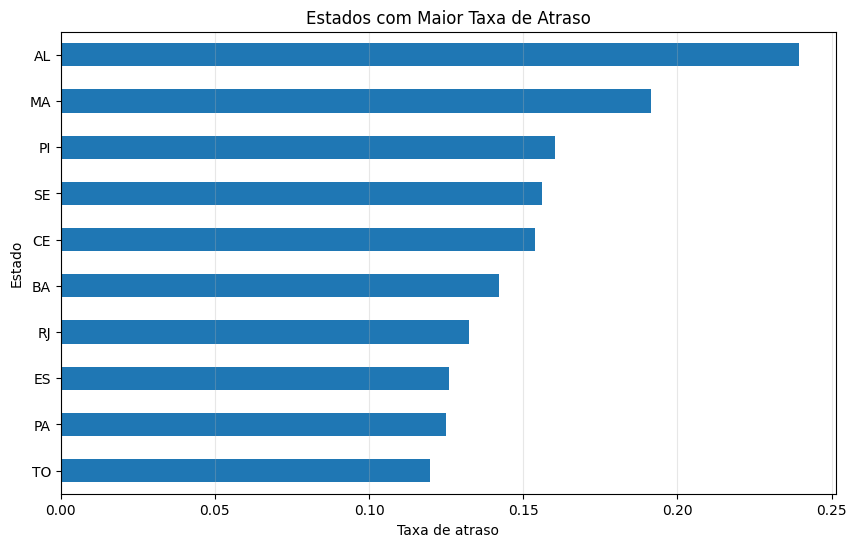

In [37]:
atraso_estado = (
    df.groupby('customer_state')['atrasado']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
atraso_estado.sort_values().plot(kind='barh')
plt.title('Estados com Maior Taxa de Atraso')
plt.xlabel('Taxa de atraso')
plt.ylabel('Estado')
plt.grid(axis='x', alpha=0.3)
plt.show()

Nota média por estado

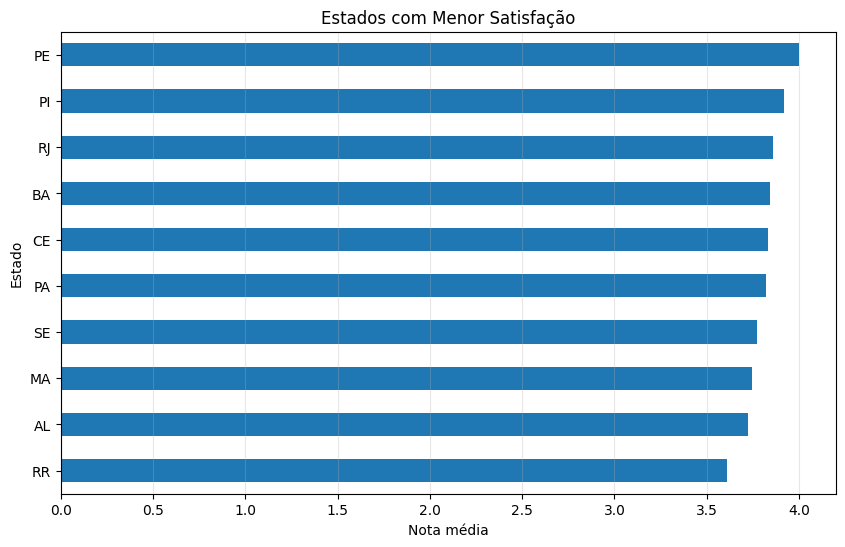

In [38]:
nota_estado = (
    df.groupby('customer_state')['review_score']
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10,6))
nota_estado.sort_values().plot(kind='barh')
plt.title('Estados com Menor Satisfação')
plt.xlabel('Nota média')
plt.ylabel('Estado')
plt.grid(axis='x', alpha=0.3)
plt.show()

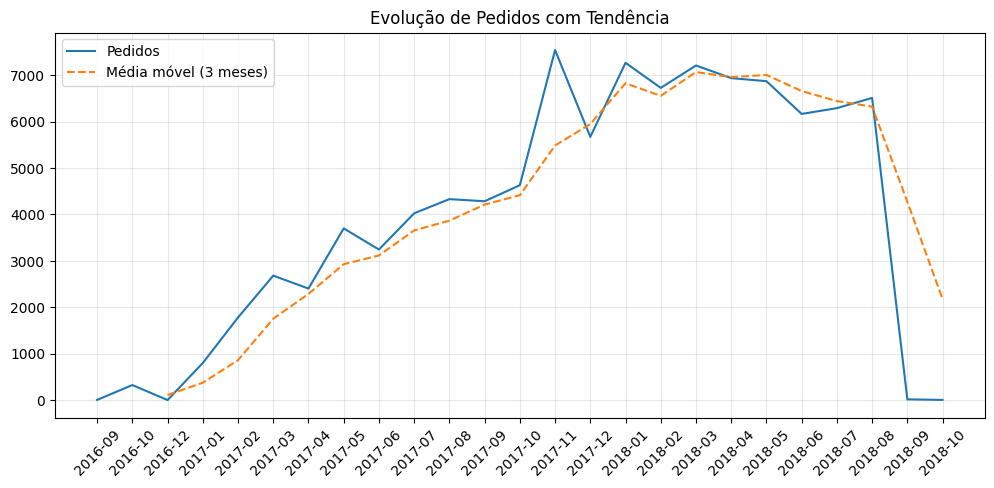

In [39]:
pedidos_mes_rolling = pedidos_mes.rolling(3).mean()

plt.figure(figsize=(12,5))
plt.plot(pedidos_mes.index.astype(str), pedidos_mes, label='Pedidos')
plt.plot(pedidos_mes_rolling.index.astype(str), pedidos_mes_rolling, label='Média móvel (3 meses)', linestyle='--')

plt.title('Evolução de Pedidos com Tendência')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

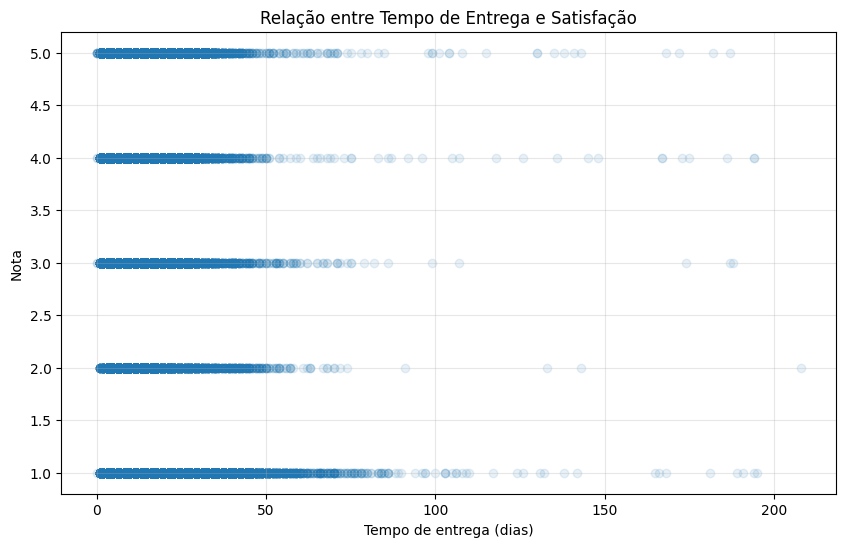

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df['tempo_entrega'], df['review_score'], alpha=0.1)

plt.title('Relação entre Tempo de Entrega e Satisfação')
plt.xlabel('Tempo de entrega (dias)')
plt.ylabel('Nota')

plt.grid(alpha=0.3)
plt.show()

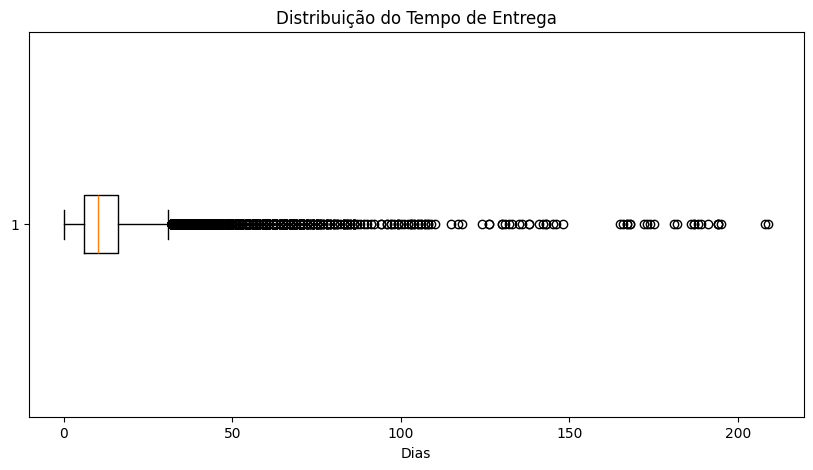

In [41]:
plt.figure(figsize=(10,5))
plt.boxplot(df['tempo_entrega'].dropna(), vert=False)

plt.title('Distribuição do Tempo de Entrega')
plt.xlabel('Dias')
plt.show()

/tmp/ipykernel_13614/3359822840.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


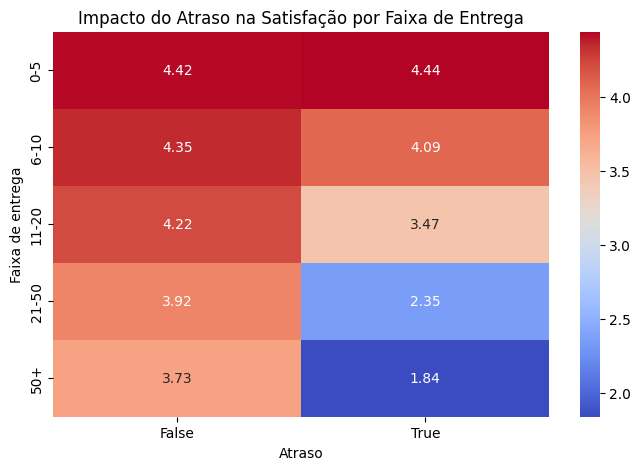

In [42]:
import seaborn as sns

pivot = df.pivot_table(
    values='review_score',
    index='faixa_entrega',
    columns='atrasado',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Impacto do Atraso na Satisfação por Faixa de Entrega')
plt.xlabel('Atraso')
plt.ylabel('Faixa de entrega')
plt.show()

In [43]:
estado_analise = df.groupby('customer_state').agg(
    receita=('payment_value','sum'),
    pedidos=('order_id','nunique'),
    atraso=('atrasado','mean'),
    nota=('review_score','mean')
).reset_index()

estado_analise.head()

,customer_state,receita,pedidos,atraso,nota
0,AC,19076.10,78,0.038462,4.012821
1,AL,94351.04,397,0.239401,3.726131
2,AM,27537.57,144,0.041379,4.195804
3,AP,16005.40,66,0.045455,4.169231
4,BA,591898.29,3215,0.142017,3.841165


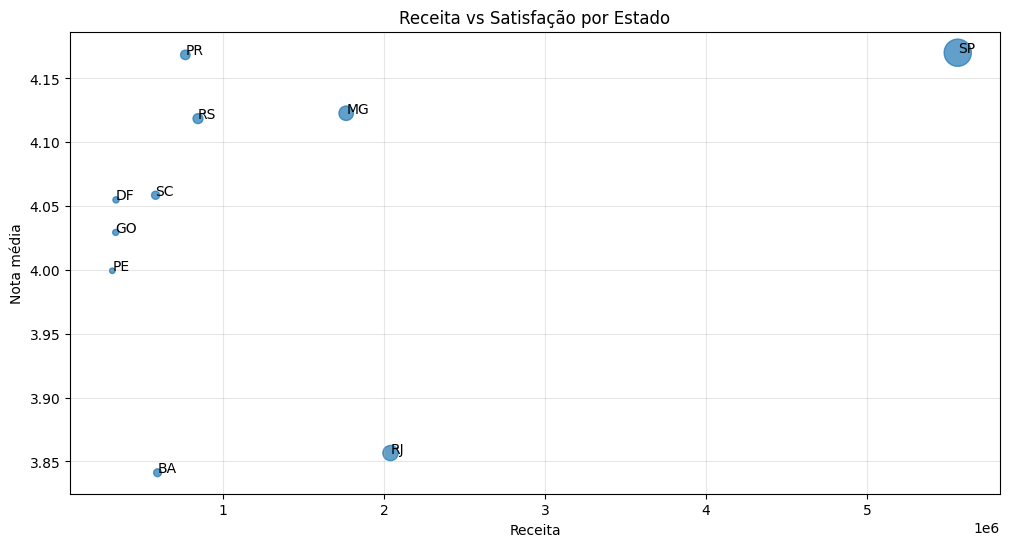

In [44]:
top_estados = estado_analise.sort_values('receita', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.scatter(top_estados['receita'], top_estados['nota'], s=top_estados['pedidos']/100, alpha=0.7)

for i, txt in enumerate(top_estados['customer_state']):
    plt.annotate(txt, (top_estados['receita'].iloc[i], top_estados['nota'].iloc[i]))

plt.title('Receita vs Satisfação por Estado')
plt.xlabel('Receita')
plt.ylabel('Nota média')
plt.grid(alpha=0.3)
plt.show()

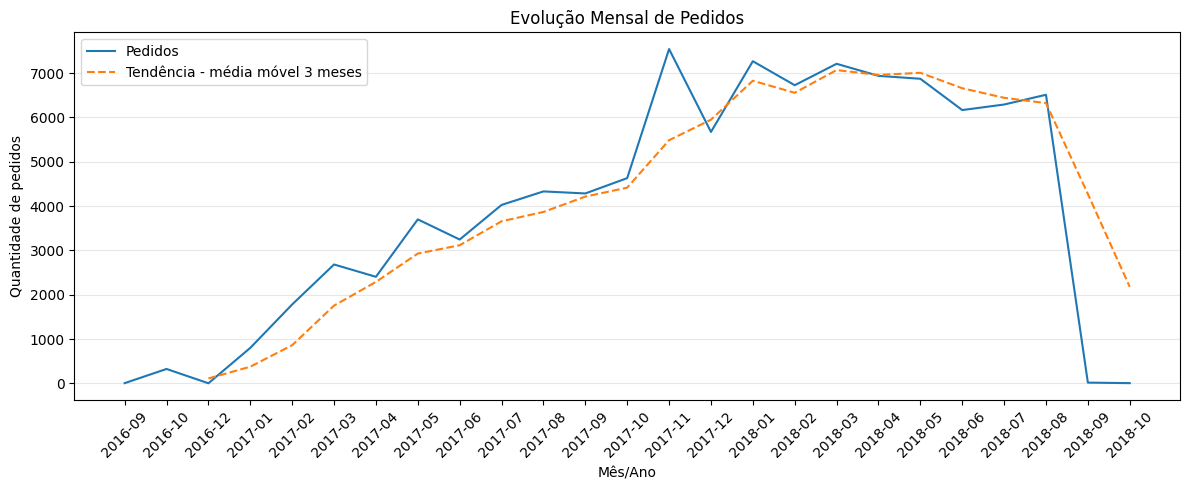

In [45]:
plt.figure(figsize=(12,5))

plt.plot(pedidos_mes.index.astype(str), pedidos_mes, label='Pedidos')
plt.plot(pedidos_mes.index.astype(str), pedidos_mes.rolling(3).mean(),
         label='Tendência - média móvel 3 meses', linestyle='--')

plt.title('Evolução Mensal de Pedidos')
plt.xlabel('Mês/Ano')
plt.ylabel('Quantidade de pedidos')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
df['tempo_entrega'].describe()

,tempo_entrega
count,90652.000000
mean,12.437343
std,9.720736
min,0.000000
25%,6.000000
50%,10.000000
75%,16.000000
max,209.000000


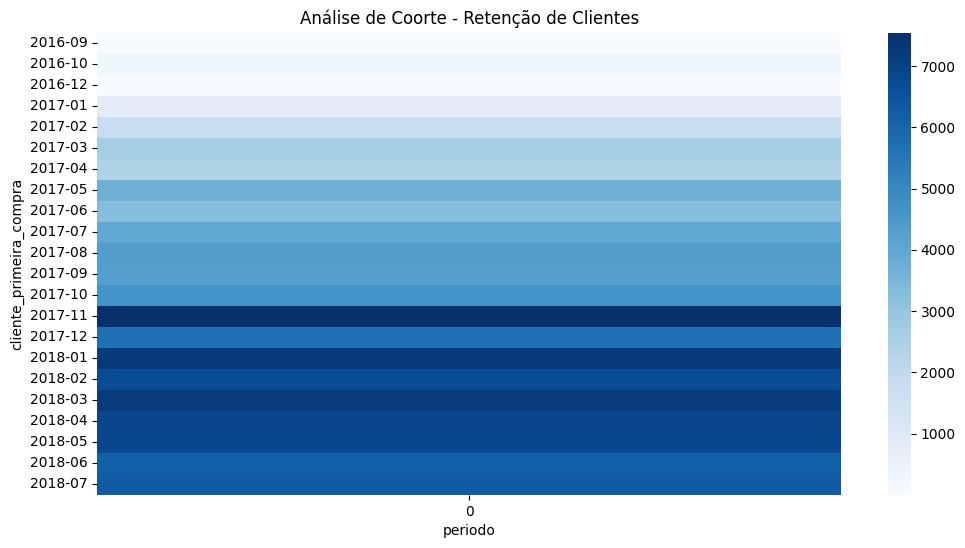

In [47]:
df['mes_compra'] = df['order_purchase_timestamp'].dt.to_period('M')
df['cliente_primeira_compra'] = df.groupby('customer_id')['mes_compra'].transform('min')

coorte = df.groupby(['cliente_primeira_compra', 'mes_compra'])['customer_id'].nunique().reset_index()

coorte['periodo'] = (coorte['mes_compra'] - coorte['cliente_primeira_compra']).apply(lambda x: x.n)

coorte_pivot = coorte.pivot(index='cliente_primeira_compra', columns='periodo', values='customer_id')

import seaborn as sns
plt.figure(figsize=(12,6))
sns.heatmap(coorte_pivot, cmap='Blues')
plt.title('Análise de Coorte - Retenção de Clientes')
plt.show()

In [48]:
ltv = df.groupby('customer_id')['payment_value'].sum()

ltv.describe()

,payment_value
count,92909.000000
mean,162.028022
std,222.792926
min,0.000000
25%,62.310000
50%,105.970000
75%,177.990000
max,13664.080000


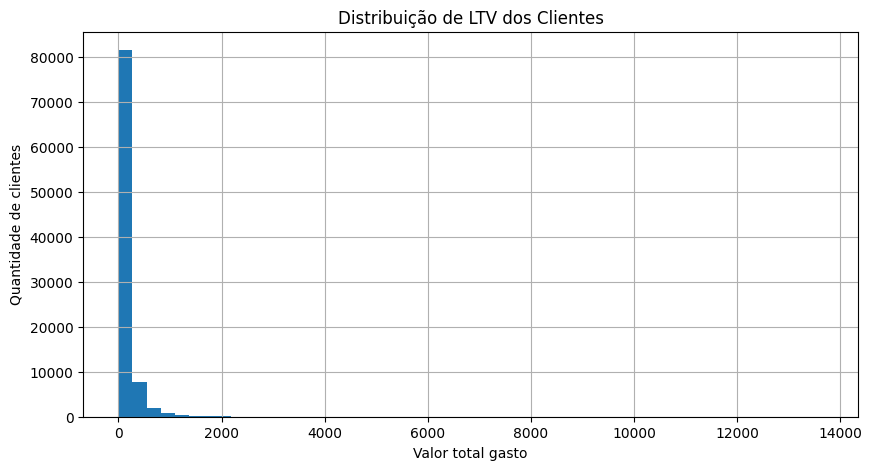

In [49]:
plt.figure(figsize=(10,5))
ltv.hist(bins=50)
plt.title('Distribuição de LTV dos Clientes')
plt.xlabel('Valor total gasto')
plt.ylabel('Quantidade de clientes')
plt.show()

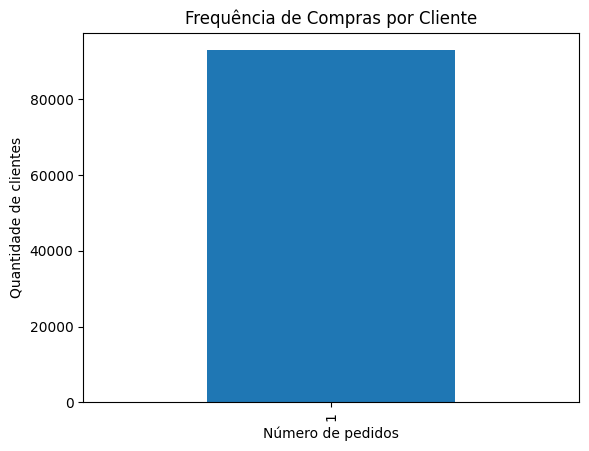

In [50]:
freq = df.groupby('customer_id')['order_id'].nunique()

freq.value_counts().sort_index().plot(kind='bar')
plt.title('Frequência de Compras por Cliente')
plt.xlabel('Número de pedidos')
plt.ylabel('Quantidade de clientes')
plt.show()

In [51]:
df = df.sort_values(['customer_id', 'order_purchase_timestamp'])

df['compra_anterior'] = df.groupby('customer_id')['order_purchase_timestamp'].shift(1)

df['tempo_recompra'] = (df['order_purchase_timestamp'] - df['compra_anterior']).dt.days

df['tempo_recompra'].describe()

,tempo_recompra
count,549.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


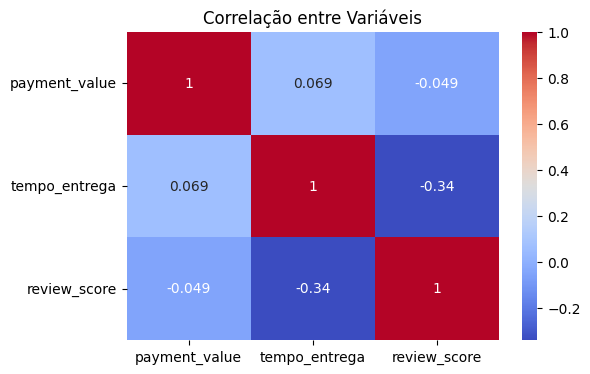

In [52]:
corr = df[['payment_value', 'tempo_entrega', 'review_score']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlação entre Variáveis')
plt.show()

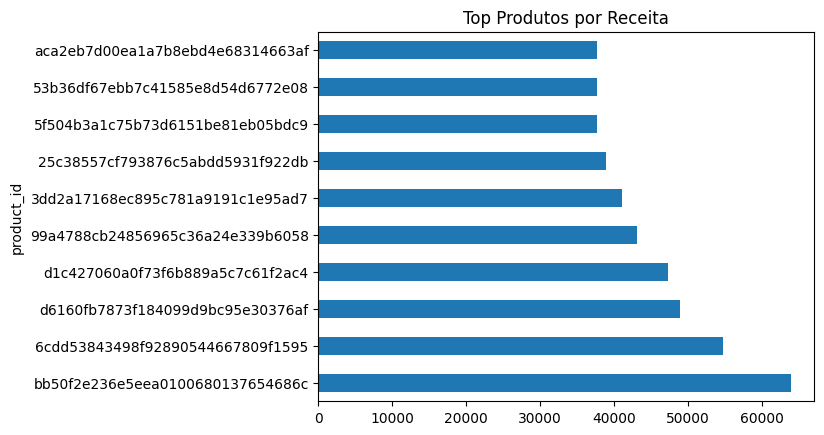

In [53]:
top_produtos = items.groupby('product_id')['price'].sum().sort_values(ascending=False).head(10)

top_produtos.plot(kind='barh')
plt.title('Top Produtos por Receita')
plt.show()

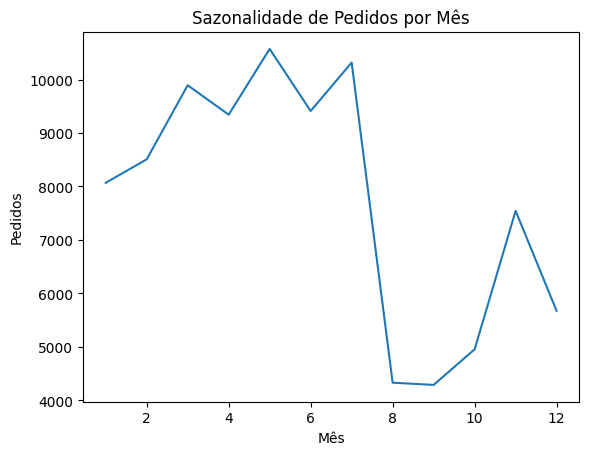

In [54]:
df['mes'] = df['order_purchase_timestamp'].dt.month

sazonalidade = df.groupby('mes')['order_id'].nunique()

sazonalidade.plot(kind='line')
plt.title('Sazonalidade de Pedidos por Mês')
plt.xlabel('Mês')
plt.ylabel('Pedidos')
plt.show()

In [55]:
df.duplicated().sum()

np.int64(3)

In [56]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,tempo_entrega,payment_value,customer_zip_code_prefix,review_score,price,compra_anterior,tempo_recompra,mes
count,93458,93369,90652,93458,90652.000000,93457.000000,93458.000000,92718.000000,92759.000000,549,549.0,93458.000000
mean,2017-12-15 08:05:16.703663616,2017-12-15 22:08:20.072872192,2017-12-29 21:31:50.776651264,2018-01-08 17:13:07.271287552,12.437343,161.077945,35424.572995,4.074980,137.959853,2017-11-02 08:32:47.448087296,0.0,5.893375
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-11 13:46:32,2016-09-30 00:00:00,0.000000,10.070000,1003.000000,1.000000,0.850000,2016-10-10 15:49:59,0.0,1.000000
25%,2017-08-31 09:50:58.249999872,2017-08-31 19:44:56,2017-09-14 15:43:47.500000,2017-09-22 00:00:00,6.000000,62.010000,11661.000000,4.000000,45.900000,2017-07-24 13:40:56,0.0,3.000000
50%,2018-01-05 23:05:42,2018-01-06 14:17:58,2018-01-20 01:08:44.500000,2018-02-01 00:00:00,10.000000,105.370000,24935.000000,5.000000,86.990000,2017-11-23 14:43:38,0.0,6.000000
75%,2018-04-13 20:04:42.249999872,2018-04-14 11:12:21,2018-04-26 22:58:47.500000,2018-05-09 00:00:00,16.000000,177.150000,59151.750000,5.000000,149.900000,2018-02-15 08:21:04,0.0,8.000000
max,2018-07-31 23:54:20,2018-08-05 23:30:50,2018-10-17 13:22:46,2018-09-20 00:00:00,209.000000,13664.080000,99990.000000,5.000000,13440.000000,2018-07-24 09:46:25,0.0,12.000000
std,NaN,NaN,NaN,NaN,9.720736,221.528269,29814.794427,1.354952,210.717575,NaN,0.0,3.301802


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93458 entries, 64414 to 24820
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       93458 non-null  object        
 1   customer_id                    93458 non-null  object        
 2   order_status                   93458 non-null  object        
 3   order_purchase_timestamp       93458 non-null  datetime64[ns]
 4   order_approved_at              93369 non-null  datetime64[ns]
 5   order_delivered_carrier_date   91798 non-null  object        
 6   order_delivered_customer_date  90652 non-null  datetime64[ns]
 7   order_estimated_delivery_date  93458 non-null  datetime64[ns]
 8   tempo_entrega                  90652 non-null  float64       
 9   atrasado                       93458 non-null  bool          
 10  mes_ano                        93458 non-null  period[M]     
 11  payment_value   

In [71]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

azul_escuro = '#1f4e79'
azul_claro = '#a6c8e0'
cinza = '#d9d9d9'

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

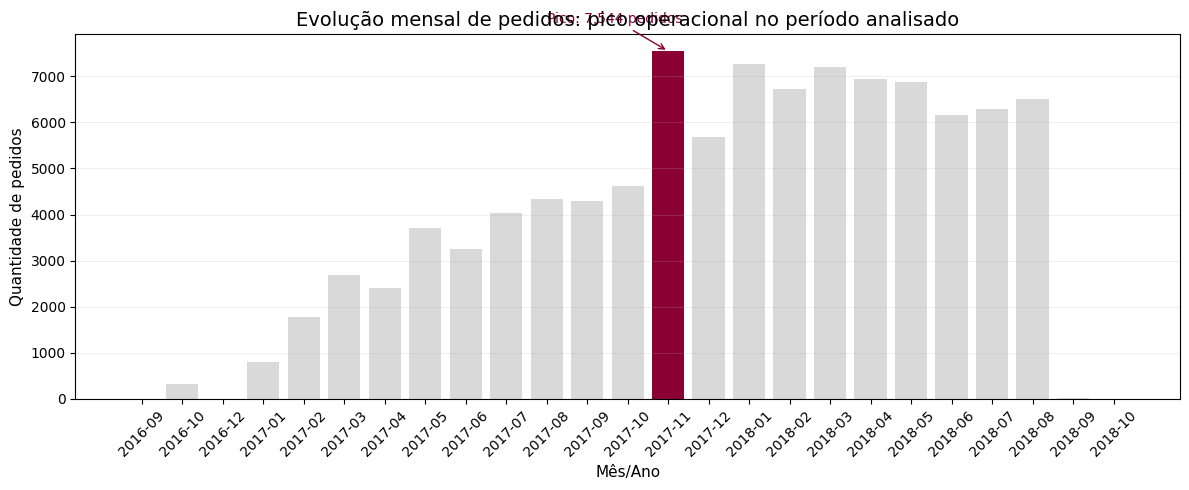

In [68]:
pedidos_mes_df = pedidos_mes.reset_index()
pedidos_mes_df.columns = ['mes_ano', 'pedidos']
pedidos_mes_df['mes_ano'] = pedidos_mes_df['mes_ano'].astype(str)

pico_idx = pedidos_mes_df['pedidos'].idxmax()

cores = [cor_destaque if i == pico_idx else cor_base for i in pedidos_mes_df.index]

plt.figure(figsize=(12,5))
plt.bar(pedidos_mes_df['mes_ano'], pedidos_mes_df['pedidos'], color=cores)

plt.title('Evolução mensal de pedidos: pico operacional no período analisado')
plt.xlabel('Mês/Ano')
plt.ylabel('Quantidade de pedidos')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)

plt.annotate(
    f"Pico: {pedidos_mes_df.loc[pico_idx, 'pedidos']:,.0f} pedidos",
    xy=(pico_idx, pedidos_mes_df.loc[pico_idx, 'pedidos']),
    xytext=(pico_idx-3, pedidos_mes_df['pedidos'].max()*1.08),
    arrowprops=dict(arrowstyle='->', color=cor_destaque),
    color=cor_destaque
)

plt.tight_layout()
plt.show()

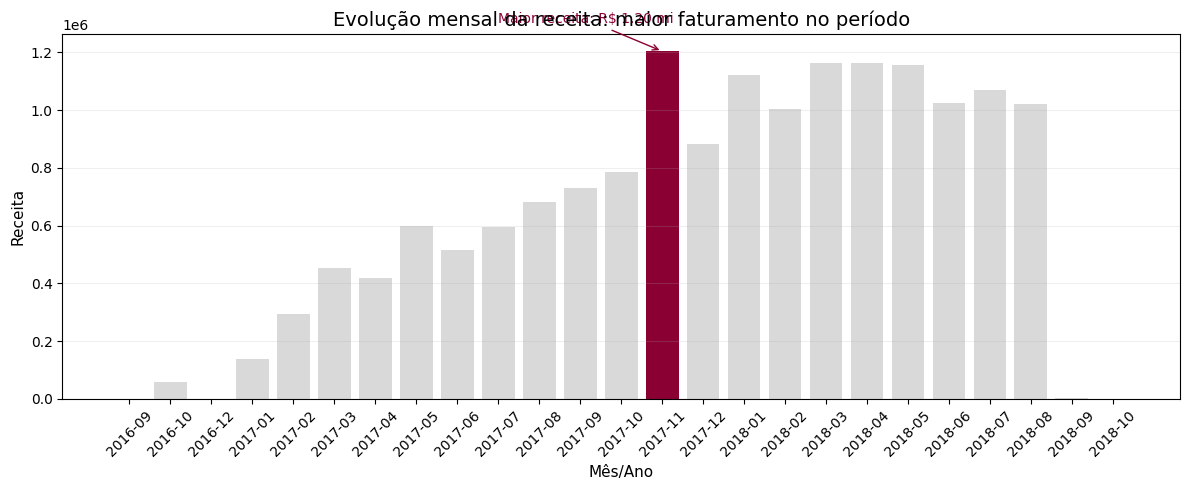

In [69]:
receita_mes_df = receita_mes.reset_index()
receita_mes_df.columns = ['mes_ano', 'receita']
receita_mes_df['mes_ano'] = receita_mes_df['mes_ano'].astype(str)

pico_receita_idx = receita_mes_df['receita'].idxmax()

cores = [cor_destaque if i == pico_receita_idx else cor_base for i in receita_mes_df.index]

plt.figure(figsize=(12,5))
plt.bar(receita_mes_df['mes_ano'], receita_mes_df['receita'], color=cores)

plt.title('Evolução mensal da receita: maior faturamento no período')
plt.xlabel('Mês/Ano')
plt.ylabel('Receita')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)

plt.annotate(
    f"Maior receita: R$ {receita_mes_df.loc[pico_receita_idx, 'receita']/1_000_000:.2f} mi",
    xy=(pico_receita_idx, receita_mes_df.loc[pico_receita_idx, 'receita']),
    xytext=(pico_receita_idx-4, receita_mes_df['receita'].max()*1.08),
    arrowprops=dict(arrowstyle='->', color=cor_destaque),
    color=cor_destaque
)

plt.tight_layout()
plt.show()

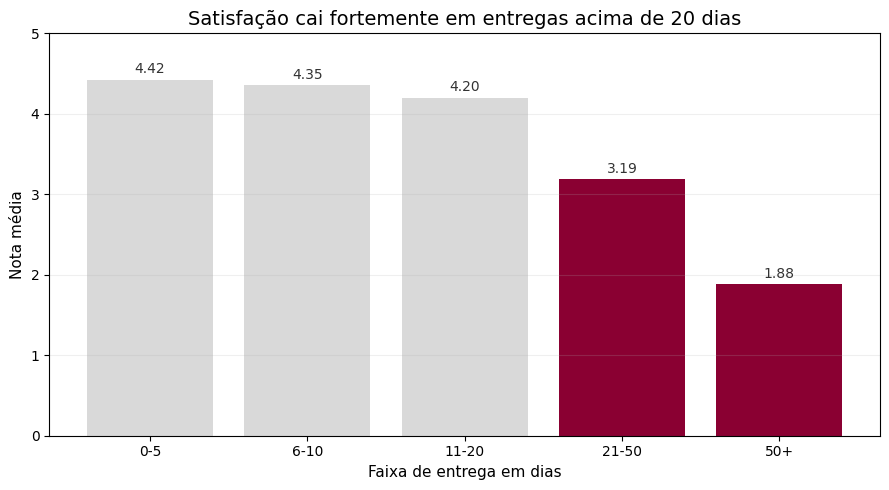

In [70]:
faixa_entrega_plot = faixa_entrega.copy()
faixa_entrega_plot['faixa_entrega'] = faixa_entrega_plot['faixa_entrega'].astype(str)

cores = [
    cor_destaque if faixa in ['21-50', '50+'] else cor_base
    for faixa in faixa_entrega_plot['faixa_entrega']
]

plt.figure(figsize=(9,5))
plt.bar(faixa_entrega_plot['faixa_entrega'], faixa_entrega_plot['nota_media'], color=cores)

plt.title('Satisfação cai fortemente em entregas acima de 20 dias')
plt.xlabel('Faixa de entrega em dias')
plt.ylabel('Nota média')
plt.ylim(0,5)
plt.grid(axis='y', alpha=0.2)

for i, valor in enumerate(faixa_entrega_plot['nota_media']):
    plt.text(i, valor + 0.08, f'{valor:.2f}', ha='center', color=cor_texto)

plt.tight_layout()
plt.show()

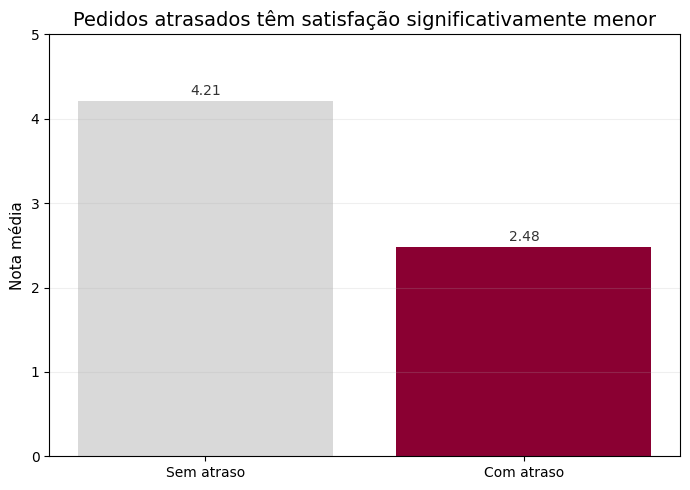

In [72]:
atraso_satisfacao = df.groupby('atrasado')['review_score'].mean().reset_index()
atraso_satisfacao['status'] = atraso_satisfacao['atrasado'].map({
    False: 'Sem atraso',
    True: 'Com atraso'
})

cores = [cor_base, cor_destaque]

plt.figure(figsize=(7,5))
plt.bar(atraso_satisfacao['status'], atraso_satisfacao['review_score'], color=cores)

plt.title('Pedidos atrasados têm satisfação significativamente menor')
plt.xlabel('')
plt.ylabel('Nota média')
plt.ylim(0,5)
plt.grid(axis='y', alpha=0.2)

for i, valor in enumerate(atraso_satisfacao['review_score']):
    plt.text(i, valor + 0.08, f'{valor:.2f}', ha='center', color=cor_texto)

plt.tight_layout()
plt.show()

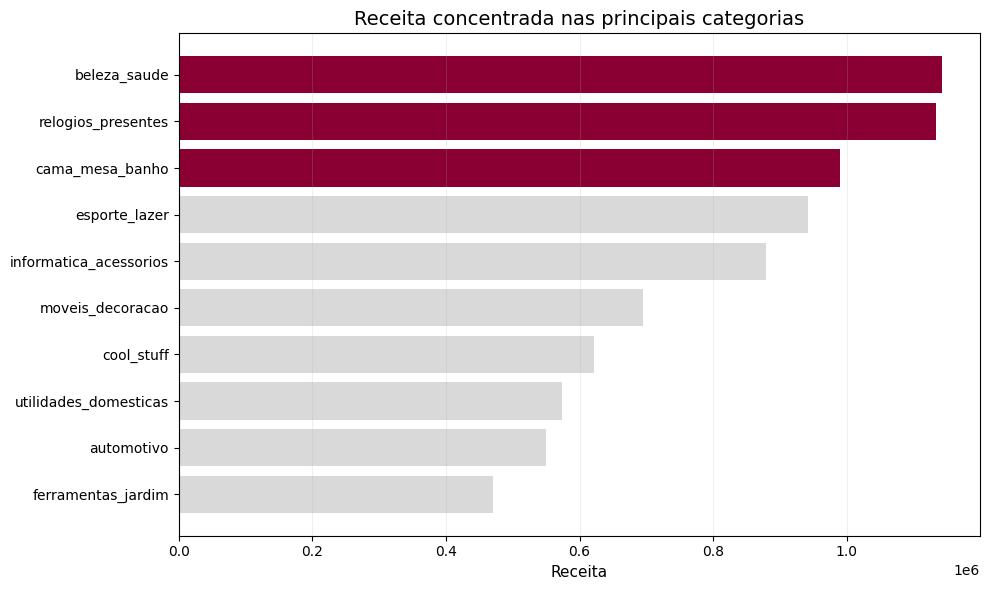

In [63]:
top_categorias_exec = (
    df_cat.groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

maiores = top_categorias_exec.sort_values(ascending=False).head(3).index

cores = [
    cor_destaque if categoria in maiores else cor_base
    for categoria in top_categorias_exec.index
]

plt.figure(figsize=(10,6))
plt.barh(top_categorias_exec.index, top_categorias_exec.values, color=cores)

plt.title('Receita concentrada nas principais categorias')
plt.xlabel('Receita')
plt.ylabel('')
plt.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

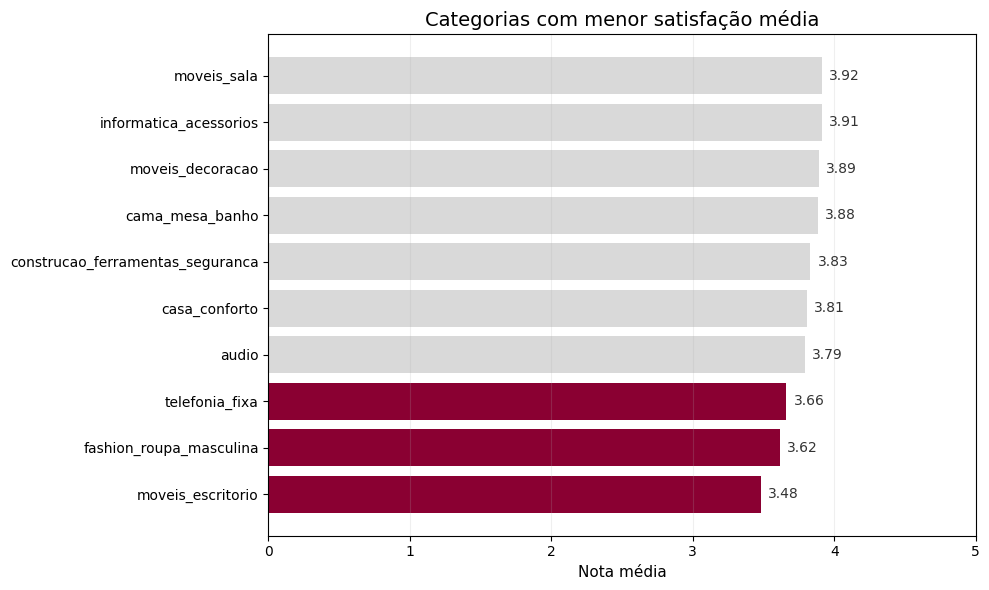

In [64]:
piores_plot = piores_categorias.sort_values('nota_media', ascending=True)

cores = [
    cor_destaque if nota <= 3.7 else cor_base
    for nota in piores_plot['nota_media']
]

plt.figure(figsize=(10,6))
plt.barh(piores_plot['product_category_name'], piores_plot['nota_media'], color=cores)

plt.title('Categorias com menor satisfação média')
plt.xlabel('Nota média')
plt.ylabel('')
plt.xlim(0,5)
plt.grid(axis='x', alpha=0.2)

for i, valor in enumerate(piores_plot['nota_media']):
    plt.text(valor + 0.05, i, f'{valor:.2f}', va='center', color=cor_texto)

plt.tight_layout()
plt.show()

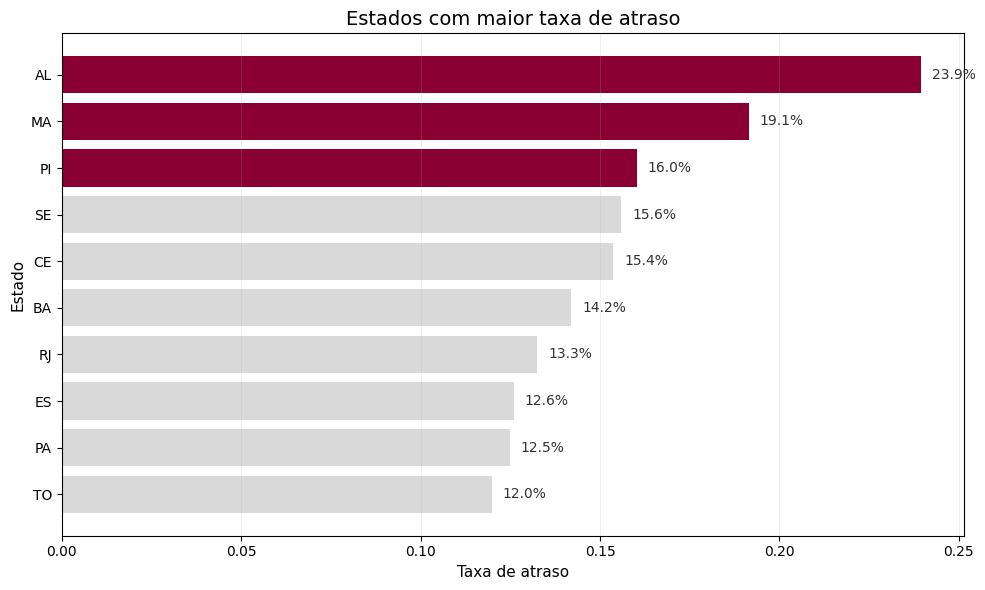

In [65]:
atraso_estado_exec = (
    df.groupby('customer_state')
    .agg(
        taxa_atraso=('atrasado', 'mean'),
        pedidos=('order_id', 'nunique')
    )
    .reset_index()
)

# filtro para evitar estado com pouco volume distorcendo análise
atraso_estado_exec = atraso_estado_exec[atraso_estado_exec['pedidos'] >= 100]

top_atraso_estado = atraso_estado_exec.sort_values('taxa_atraso', ascending=False).head(10)
top_atraso_estado = top_atraso_estado.sort_values('taxa_atraso')

cores = [
    cor_destaque if valor >= top_atraso_estado['taxa_atraso'].quantile(0.75) else cor_base
    for valor in top_atraso_estado['taxa_atraso']
]

plt.figure(figsize=(10,6))
plt.barh(top_atraso_estado['customer_state'], top_atraso_estado['taxa_atraso'], color=cores)

plt.title('Estados com maior taxa de atraso')
plt.xlabel('Taxa de atraso')
plt.ylabel('Estado')
plt.grid(axis='x', alpha=0.2)

for i, valor in enumerate(top_atraso_estado['taxa_atraso']):
    plt.text(valor + 0.003, i, f'{valor:.1%}', va='center', color=cor_texto)

plt.tight_layout()
plt.show()

In [66]:
kpis = pd.DataFrame({
    'Indicador': [
        'Pedidos',
        'Receita total',
        'Ticket médio',
        'Tempo médio de entrega',
        'Taxa de atraso',
        'Nota média'
    ],
    'Valor': [
        f"{df['order_id'].nunique():,.0f}",
        f"R$ {df['payment_value'].sum()/1_000_000:.1f} mi",
        f"R$ {(df['payment_value'].sum() / df['order_id'].nunique()):.2f}",
        f"{df['tempo_entrega'].mean():.1f} dias",
        f"{df['atrasado'].mean():.1%}",
        f"{df['review_score'].mean():.2f}"
    ]
})

kpis

,Indicador,Valor
0,Pedidos,"92,909"
1,Receita total,R$ 15.1 mi
2,Ticket médio,R$ 162.03
3,Tempo médio de entrega,12.4 dias
4,Taxa de atraso,7.7%
5,Nota média,4.07


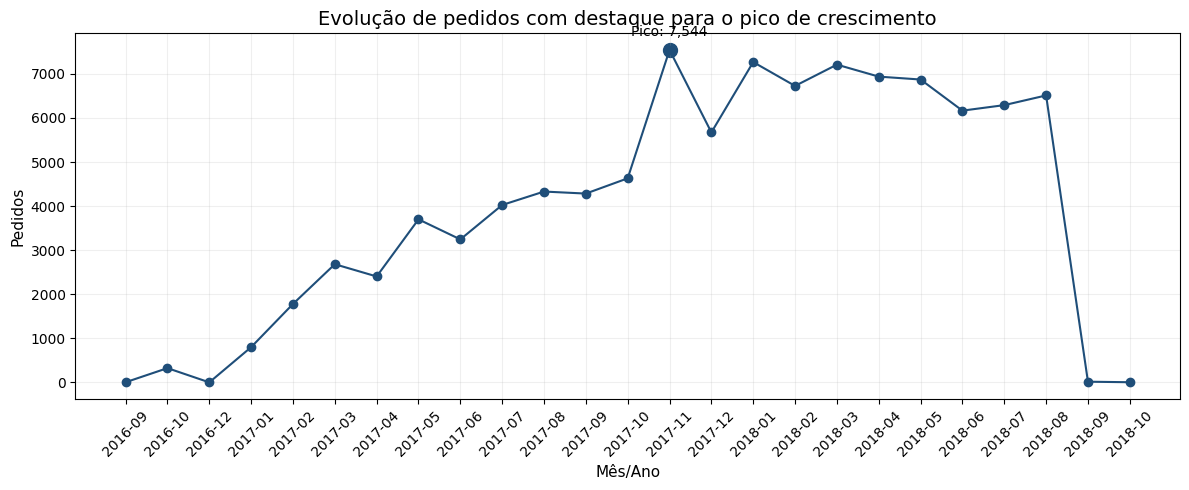

In [73]:
df_plot = pedidos_mes.reset_index()
df_plot.columns = ['mes', 'pedidos']
df_plot['mes'] = df_plot['mes'].astype(str)

pico = df_plot['pedidos'].idxmax()

plt.figure(figsize=(12,5))

plt.plot(df_plot['mes'], df_plot['pedidos'], color=azul_escuro, marker='o')

# destaque do pico
plt.scatter(df_plot['mes'][pico], df_plot['pedidos'][pico], color=azul_escuro, s=100)

# anotação
plt.annotate(
    f"Pico: {df_plot['pedidos'][pico]:,.0f}",
    (df_plot['mes'][pico], df_plot['pedidos'][pico]),
    textcoords="offset points",
    xytext=(0,10),
    ha='center'
)

plt.title('Evolução de pedidos com destaque para o pico de crescimento')
plt.xlabel('Mês/Ano')
plt.ylabel('Pedidos')
plt.xticks(rotation=45)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

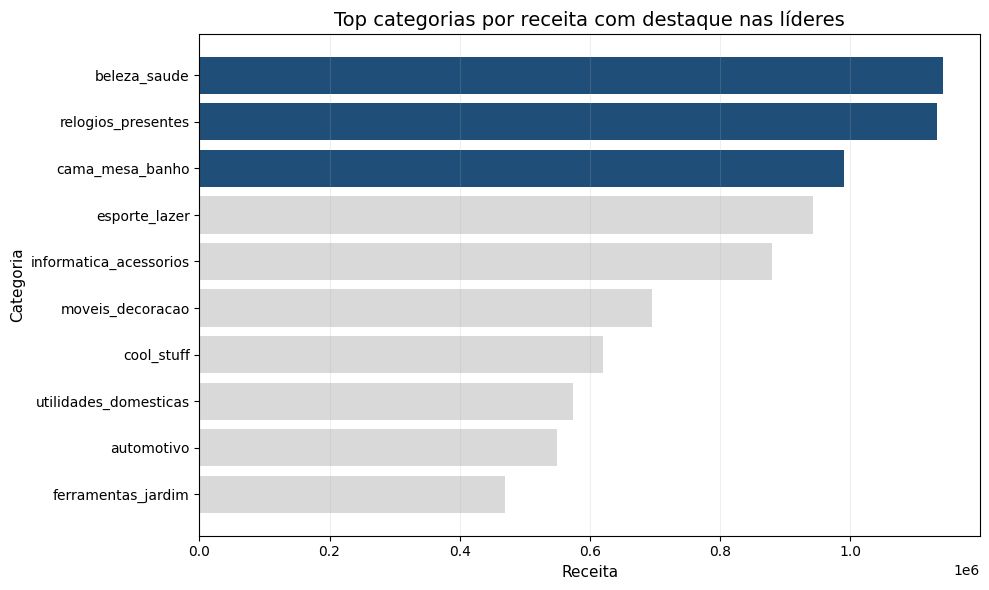

In [74]:
top = (
    df_cat.groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

top3 = top.tail(3).index

cores = [azul_escuro if i in top3 else cinza for i in top.index]

plt.figure(figsize=(10,6))
plt.barh(top.index, top.values, color=cores)

plt.title('Top categorias por receita com destaque nas líderes')
plt.xlabel('Receita')
plt.ylabel('Categoria')
plt.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

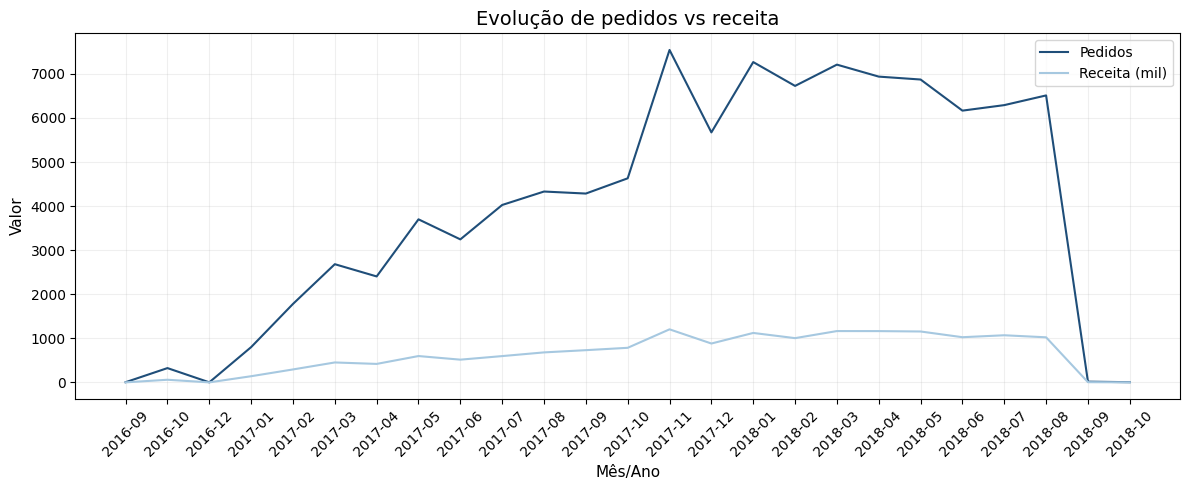

In [75]:
plt.figure(figsize=(12,5))

plt.plot(pedidos_mes.index.astype(str), pedidos_mes, label='Pedidos', color=azul_escuro)
plt.plot(receita_mes.index.astype(str), receita_mes/1000, label='Receita (mil)', color=azul_claro)

plt.title('Evolução de pedidos vs receita')
plt.xlabel('Mês/Ano')
plt.ylabel('Valor')
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

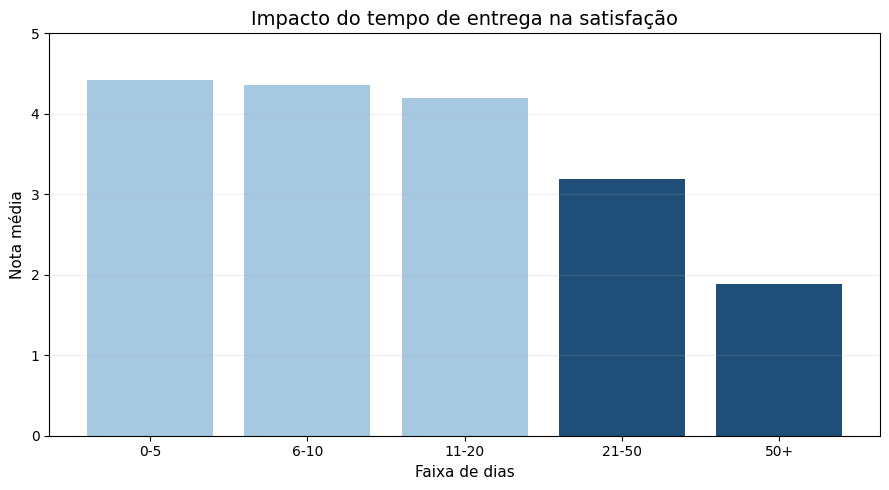

In [76]:
dados = faixa_entrega.copy()

cores = [
    azul_escuro if faixa in ['21-50', '50+'] else azul_claro
    for faixa in dados['faixa_entrega']
]

plt.figure(figsize=(9,5))
plt.bar(dados['faixa_entrega'], dados['nota_media'], color=cores)

plt.title('Impacto do tempo de entrega na satisfação')
plt.xlabel('Faixa de dias')
plt.ylabel('Nota média')
plt.ylim(0,5)
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

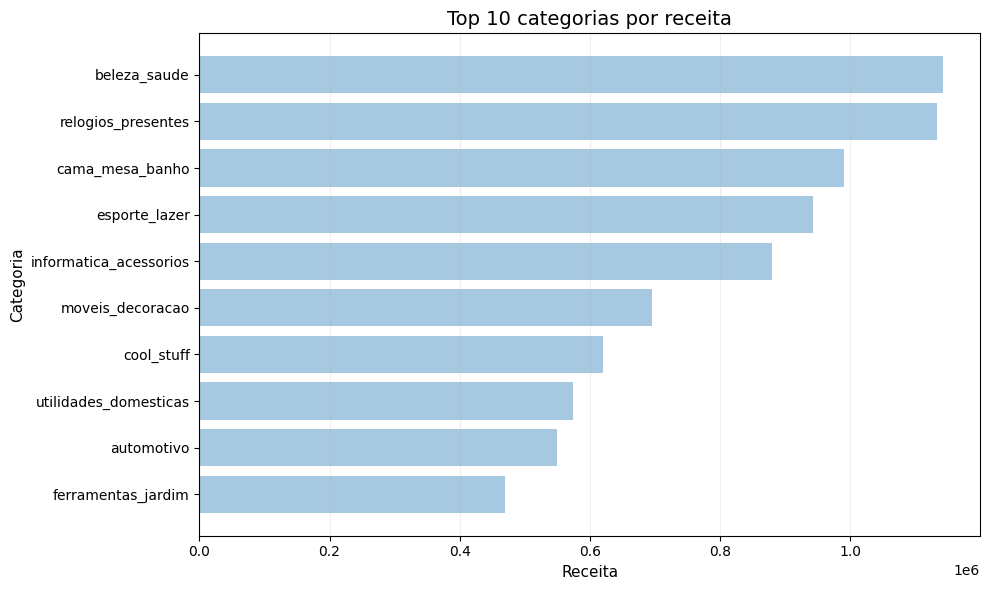

In [77]:
azul_escuro = '#1f4e79'
azul_claro = '#a6c8e0'
cinza = '#d9d9d9'

top_categorias_base = (
    df_cat.groupby('product_category_name')
    .agg(
        receita=('price', 'sum'),
        pedidos=('order_id', 'nunique')
    )
    .reset_index()
)

top_categorias_base['ticket_medio_categoria'] = (
    top_categorias_base['receita'] / top_categorias_base['pedidos']
)

top10_receita = (
    top_categorias_base
    .sort_values('receita', ascending=False)
    .head(10)
    .sort_values('receita')
)

plt.figure(figsize=(10,6))
plt.barh(top10_receita['product_category_name'], top10_receita['receita'], color=azul_claro)

plt.title('Top 10 categorias por receita')
plt.xlabel('Receita')
plt.ylabel('Categoria')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

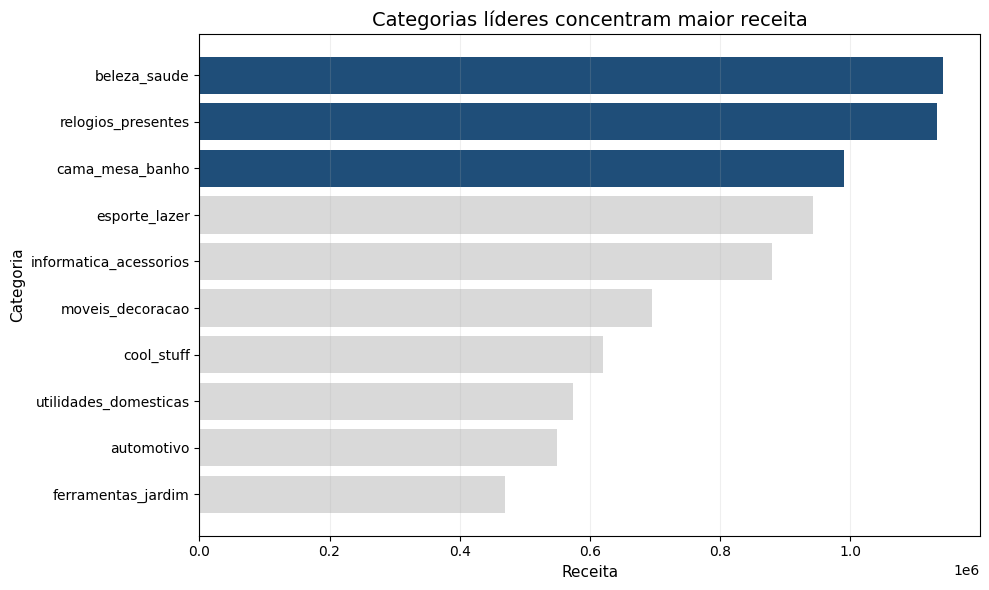

In [78]:
top3_receita = top10_receita.sort_values('receita', ascending=False).head(3)['product_category_name']

cores = [
    azul_escuro if cat in list(top3_receita) else cinza
    for cat in top10_receita['product_category_name']
]

plt.figure(figsize=(10,6))
plt.barh(top10_receita['product_category_name'], top10_receita['receita'], color=cores)

plt.title('Categorias líderes concentram maior receita')
plt.xlabel('Receita')
plt.ylabel('Categoria')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

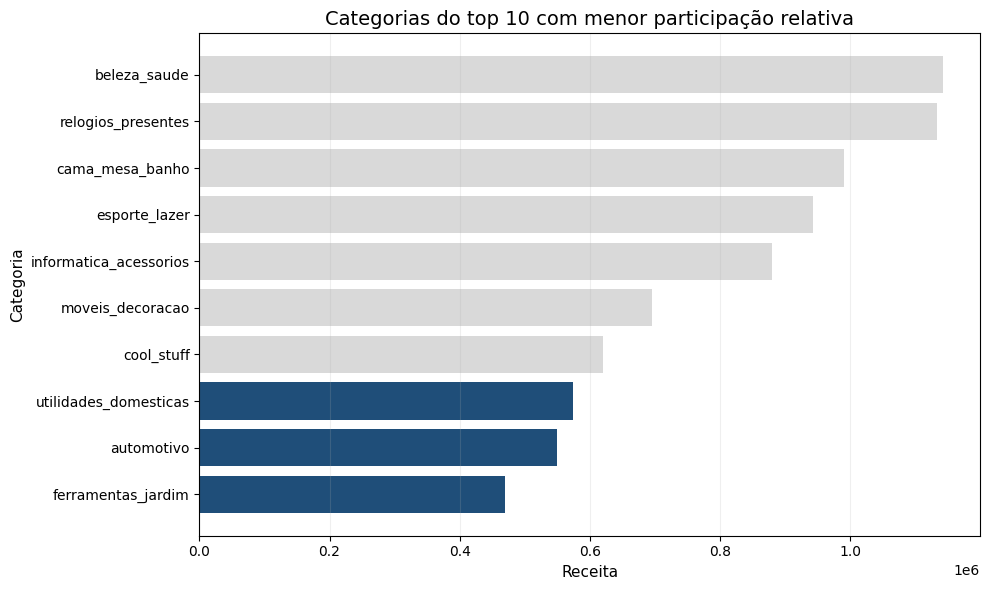

In [79]:
bottom3_top10 = top10_receita.sort_values('receita', ascending=True).head(3)['product_category_name']

cores = [
    azul_escuro if cat in list(bottom3_top10) else cinza
    for cat in top10_receita['product_category_name']
]

plt.figure(figsize=(10,6))
plt.barh(top10_receita['product_category_name'], top10_receita['receita'], color=cores)

plt.title('Categorias do top 10 com menor participação relativa')
plt.xlabel('Receita')
plt.ylabel('Categoria')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

In [80]:
top10_metricas = top_categorias_base.sort_values('receita', ascending=False).head(10)

top10_metricas[['product_category_name', 'receita', 'pedidos', 'ticket_medio_categoria']]

,product_category_name,receita,pedidos,ticket_medio_categoria
11,beleza_saude,1142334.60,8058,141.764036
66,relogios_presentes,1133798.27,5232,216.704562
13,cama_mesa_banho,989900.73,8859,111.739556
32,esporte_lazer,942119.42,7284,129.340942
44,informatica_acessorios,879346.61,6305,139.468138
54,moveis_decoracao,694902.32,6105,113.825114
26,cool_stuff,620903.93,3512,176.794969
72,utilidades_domesticas,574339.93,5322,107.918063
8,automotivo,548982.21,3545,154.860990
40,ferramentas_jardim,470000.11,3396,138.398148


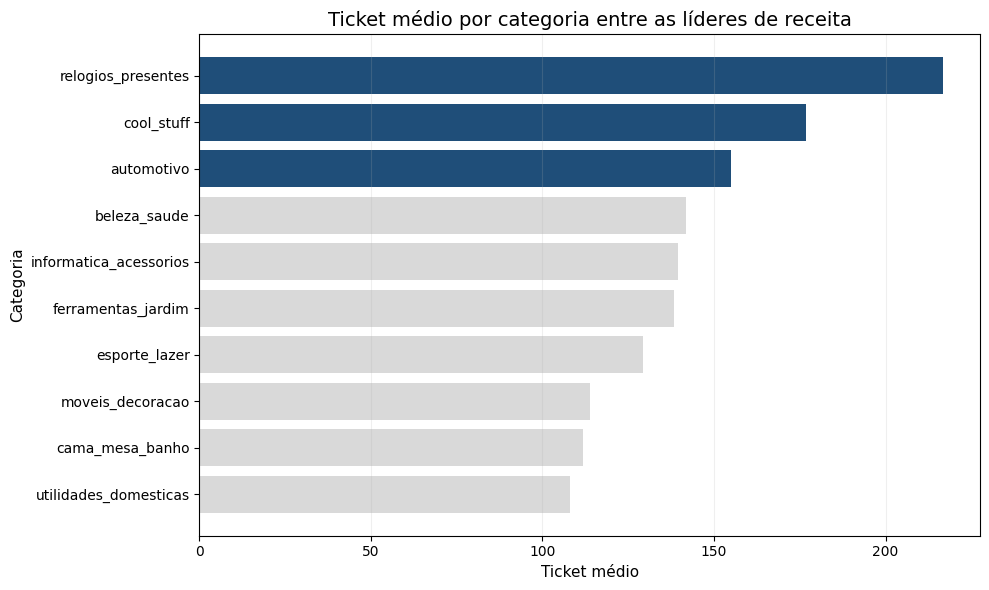

In [81]:
top10_ticket = top10_metricas.sort_values('ticket_medio_categoria').tail(10)

cores = [
    azul_escuro if valor >= top10_ticket['ticket_medio_categoria'].quantile(0.75) else cinza
    for valor in top10_ticket['ticket_medio_categoria']
]

plt.figure(figsize=(10,6))
plt.barh(top10_ticket['product_category_name'], top10_ticket['ticket_medio_categoria'], color=cores)

plt.title('Ticket médio por categoria entre as líderes de receita')
plt.xlabel('Ticket médio')
plt.ylabel('Categoria')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

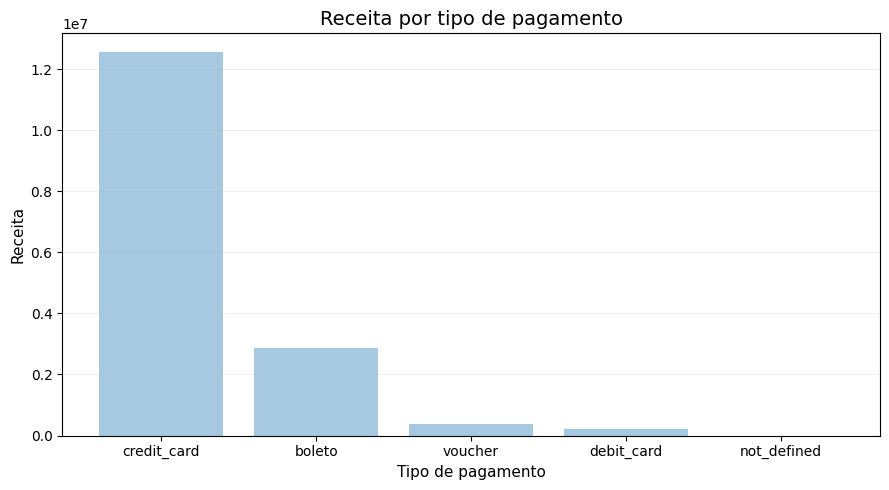

In [82]:
pagamentos_tipo = (
    payments.groupby('payment_type')['payment_value']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))
plt.bar(pagamentos_tipo.index, pagamentos_tipo.values, color=azul_claro)

plt.title('Receita por tipo de pagamento')
plt.xlabel('Tipo de pagamento')
plt.ylabel('Receita')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

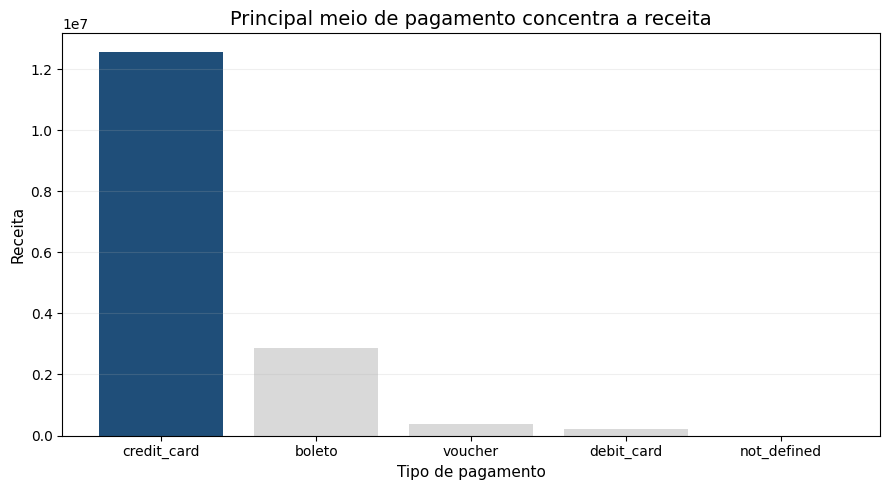

In [83]:
principal_pagamento = pagamentos_tipo.idxmax()

cores = [
    azul_escuro if tipo == principal_pagamento else cinza
    for tipo in pagamentos_tipo.index
]

plt.figure(figsize=(9,5))
plt.bar(pagamentos_tipo.index, pagamentos_tipo.values, color=cores)

plt.title('Principal meio de pagamento concentra a receita')
plt.xlabel('Tipo de pagamento')
plt.ylabel('Receita')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

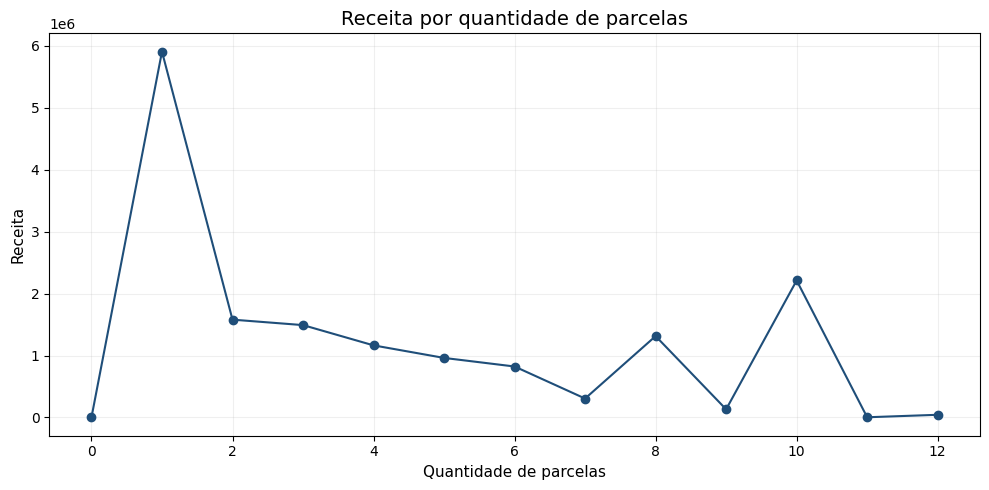

In [84]:
parcelas = (
    payments.groupby('payment_installments')['payment_value']
    .sum()
    .reset_index()
)

parcelas = parcelas[parcelas['payment_installments'] <= 12]

plt.figure(figsize=(10,5))
plt.plot(parcelas['payment_installments'], parcelas['payment_value'], marker='o', color=azul_escuro)

plt.title('Receita por quantidade de parcelas')
plt.xlabel('Quantidade de parcelas')
plt.ylabel('Receita')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

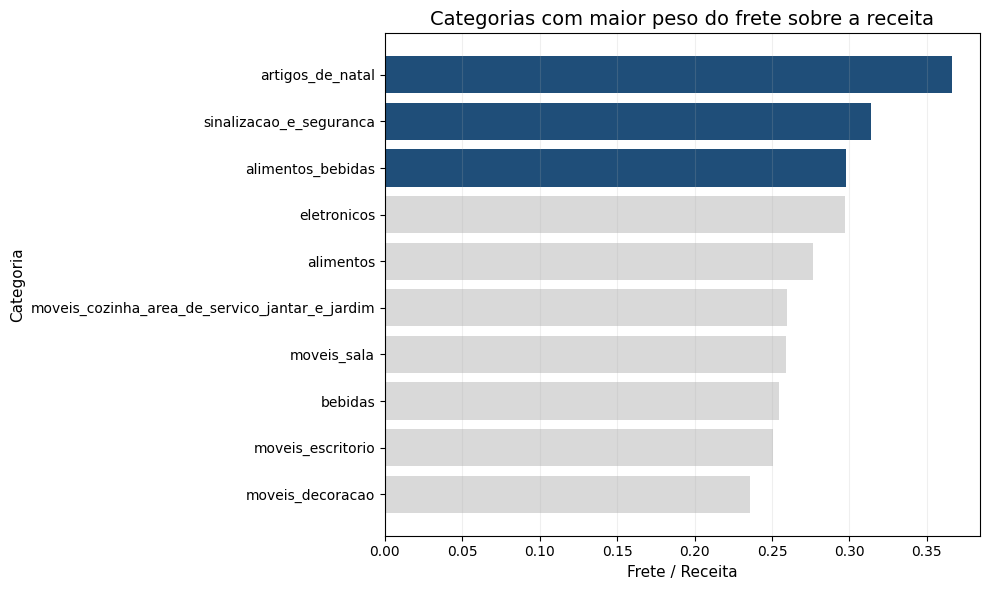

In [85]:
frete_categoria = (
    df_cat.groupby('product_category_name')
    .agg(
        receita=('price', 'sum'),
        frete=('freight_value', 'sum'),
        pedidos=('order_id', 'nunique')
    )
    .reset_index()
)

frete_categoria['perc_frete'] = frete_categoria['frete'] / frete_categoria['receita']

frete_categoria_filtrada = frete_categoria[frete_categoria['pedidos'] >= 100]

top_frete = (
    frete_categoria_filtrada
    .sort_values('perc_frete', ascending=False)
    .head(10)
    .sort_values('perc_frete')
)

cores = [
    azul_escuro if valor >= top_frete['perc_frete'].quantile(0.75) else cinza
    for valor in top_frete['perc_frete']
]

plt.figure(figsize=(10,6))
plt.barh(top_frete['product_category_name'], top_frete['perc_frete'], color=cores)

plt.title('Categorias com maior peso do frete sobre a receita')
plt.xlabel('Frete / Receita')
plt.ylabel('Categoria')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()